Projeto G2 — Evolução dos Casos de Dengue no Brasil

Disciplina: Linguagens de Programação
Projeto: G1 — Tema 1
Período analisado: 2015 a 2024
Professor: Alexandre Louzada
Aluno: Lucas Lima Ribeiro

## 1. Introdução

A dengue é uma das principais doenças transmitidas por mosquitos no Brasil e representa um importante problema de saúde pública. A ocorrência da doença pode estar relacionada a diferentes fatores, entre eles condições climáticas, ambientais e urbanas.

Neste projeto, será realizada uma análise dos casos de dengue registrados em municípios brasileiros entre os anos de 2015 e 2024. A análise busca compreender a evolução temporal da doença, identificar regiões e estados mais afetados, observar períodos de maior ocorrência e investigar possíveis relações entre as condições climáticas, especialmente o volume de chuva, e a quantidade de casos registrados.

Por meio da utilização de Python e das bibliotecas Pandas, NumPy, Matplotlib e Seaborn, serão realizados procedimentos de tratamento, preparação e análise exploratória dos dados. Os resultados obtidos também servirão de base para a construção de indicadores e visualizações que posteriormente serão utilizados no dashboard interativo desenvolvido com Streamlit.

O objetivo é transformar os dados disponíveis em informações que permitam identificar padrões relevantes e contribuir para uma melhor compreensão da evolução da dengue no Brasil.


## 2. Definição do problema

### Pergunta principal

**Como os casos de dengue evoluíram no Brasil entre 2015 e 2024 e quais regiões, estados e períodos apresentaram maior concentração de casos e incidência?**

### Perguntas complementares

* Quais estados apresentam maior número de casos?
* Existem períodos do ano com maior concentração de casos?
* Como os casos evoluíram ao longo dos anos?
* Existe relação entre o volume de chuva e a quantidade de casos de dengue?
* Quais municípios apresentam maior incidência?
* Quais regiões apresentam maior nível de alerta?
* Quais períodos podem ser considerados críticos para a saúde pública?

### Relevância

Responder essas perguntas permite identificar padrões temporais e regionais da ocorrência da dengue. A análise pode auxiliar na compreensão dos períodos de maior risco e na identificação de regiões que apresentam maior concentração de casos, contribuindo para uma interpretação mais clara dos dados epidemiológicos.


In [1]:
# Importação das bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração dos gráficos
sns.set_theme(style="whitegrid")

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Importação da base de dados

from google.colab import files

arquivo = files.upload()

Saving simulacao_dengue_brasil.csv to simulacao_dengue_brasil.csv


In [3]:
# Leitura da base de dados

df = pd.read_csv("simulacao_dengue_brasil.csv")

print("Base carregada com sucesso!")
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Base carregada com sucesso!
Quantidade de linhas: 4440
Quantidade de colunas: 14


In [4]:
# Visualização das primeiras linhas

df.head()

,ano,mes,data,regiao,uf,municipio,populacao,chuva_mm,temperatura_media,casos_dengue,internacoes,obitos,incidencia_100k,nivel_alerta
0,2015,1,2015-01-01,Norte,AM,Manaus,2708209,141.6,26.6,998,43,2,36.85,Médio
1,2015,1,2015-01-01,Norte,PA,Belém,711775,161.5,26.4,229,12,0,32.17,Médio
2,2015,1,2015-01-01,Norte,PA,Santarém,2249561,128.9,26.1,776,35,2,34.50,Médio
3,2015,1,2015-01-01,Norte,RO,Porto Velho,2198291,180.8,28.5,915,51,3,41.62,Médio
4,2015,1,2015-01-01,Norte,TO,Palmas,2193271,151.1,24.7,760,37,0,34.65,Médio


In [5]:
# Verificação dos tipos de dados

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ano                4440 non-null   int64  
 1   mes                4440 non-null   int64  
 2   data               4440 non-null   object 
 3   regiao             4440 non-null   object 
 4   uf                 4440 non-null   object 
 5   municipio          4440 non-null   object 
 6   populacao          4440 non-null   int64  
 7   chuva_mm           4440 non-null   float64
 8   temperatura_media  4440 non-null   float64
 9   casos_dengue       4440 non-null   int64  
 10  internacoes        4440 non-null   int64  
 11  obitos             4440 non-null   int64  
 12  incidencia_100k    4440 non-null   float64
 13  nivel_alerta       4440 non-null   object 
dtypes: float64(3), int64(6), object(5)
memory usage: 485.8+ KB


In [6]:
# Verificação de valores nulos

df.isnull().sum()

,0
ano,0
mes,0
data,0
regiao,0
uf,0
municipio,0
populacao,0
chuva_mm,0
temperatura_media,0
casos_dengue,0


In [7]:
# Verificação de registros duplicados

duplicados = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicados}")

Quantidade de registros duplicados: 0


In [8]:
# Verificação dos valores mínimos e máximos

print("Ano mínimo:", df["ano"].min())
print("Ano máximo:", df["ano"].max())

print("Mês mínimo:", df["mes"].min())
print("Mês máximo:", df["mes"].max())

print("Casos de dengue - mínimo:", df["casos_dengue"].min())
print("Internações - mínimo:", df["internacoes"].min())
print("Óbitos - mínimo:", df["obitos"].min())

print("População - mínimo:", df["populacao"].min())
print("Chuva - mínimo:", df["chuva_mm"].min())
print("Incidência - mínimo:", df["incidencia_100k"].min())

Ano mínimo: 2015
Ano máximo: 2024
Mês mínimo: 1
Mês máximo: 12
Casos de dengue - mínimo: 26
Internações - mínimo: 0
Óbitos - mínimo: 0
População - mínimo: 150048
Chuva - mínimo: 0.0
Incidência - mínimo: 11.69


In [9]:
# Conversão da coluna data para o formato datetime

df["data"] = pd.to_datetime(df["data"])

print("Coluna 'data' convertida com sucesso!")
print(df["data"].dtype)

Coluna 'data' convertida com sucesso!
datetime64[ns]


In [10]:
# Criação do nome do mês

meses = {
    1: "Janeiro",
    2: "Fevereiro",
    3: "Março",
    4: "Abril",
    5: "Maio",
    6: "Junho",
    7: "Julho",
    8: "Agosto",
    9: "Setembro",
    10: "Outubro",
    11: "Novembro",
    12: "Dezembro"
}

df["mes_nome"] = df["mes"].map(meses)

df[["mes", "mes_nome"]].head()

,mes,mes_nome
0,1,Janeiro
1,1,Janeiro
2,1,Janeiro
3,1,Janeiro
4,1,Janeiro


In [11]:
# Criação de indicadores de internação e óbito

df["taxa_internacao"] = (
    df["internacoes"] / df["casos_dengue"]
) * 100

df["taxa_obito"] = (
    df["obitos"] / df["casos_dengue"]
) * 100

# Visualização dos novos indicadores
df[[
    "casos_dengue",
    "internacoes",
    "obitos",
    "taxa_internacao",
    "taxa_obito"
]].head()

,casos_dengue,internacoes,obitos,taxa_internacao,taxa_obito
0,998,43,2,4.308617,0.200401
1,229,12,0,5.240175,0.000000
2,776,35,2,4.510309,0.257732
3,915,51,3,5.573770,0.327869
4,760,37,0,4.868421,0.000000


In [12]:
# KPIs principais do projeto

total_casos = df["casos_dengue"].sum()
total_obitos = df["obitos"].sum()
media_mensal_casos = df.groupby("data")["casos_dengue"].sum().mean()

estado_mais_casos = (
    df.groupby("uf")["casos_dengue"]
    .sum()
    .idxmax()
)

municipio_mais_casos = (
    df.groupby("municipio")["casos_dengue"]
    .sum()
    .idxmax()
)

media_incidencia = df["incidencia_100k"].mean()

print("===== KPIs PRINCIPAIS =====")
print(f"Total de casos de dengue: {total_casos:,}")
print(f"Total de óbitos: {total_obitos:,}")
print(f"Média mensal de casos: {media_mensal_casos:,.2f}")
print(f"Estado com mais casos: {estado_mais_casos}")
print(f"Município com mais casos: {municipio_mais_casos}")
print(f"Incidência média por 100 mil habitantes: {media_incidencia:.2f}")

===== KPIs PRINCIPAIS =====
Total de casos de dengue: 3,560,562
Total de óbitos: 5,314
Média mensal de casos: 29,671.35
Estado com mais casos: RJ
Município com mais casos: Vila Velha
Incidência média por 100 mil habitantes: 30.94


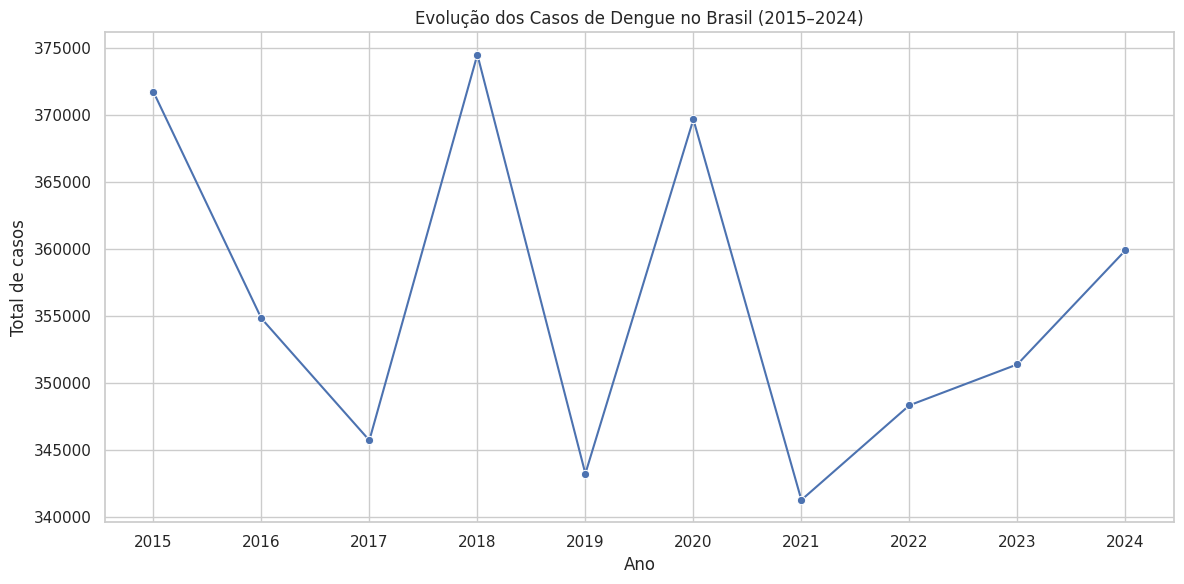

In [13]:
# Evolução dos casos de dengue por ano

casos_por_ano = (
    df.groupby("ano")["casos_dengue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=casos_por_ano,
    x="ano",
    y="casos_dengue",
    marker="o"
)

plt.title("Evolução dos Casos de Dengue no Brasil (2015–2024)")
plt.xlabel("Ano")
plt.ylabel("Total de casos")
plt.xticks(casos_por_ano["ano"])
plt.tight_layout()
plt.show()

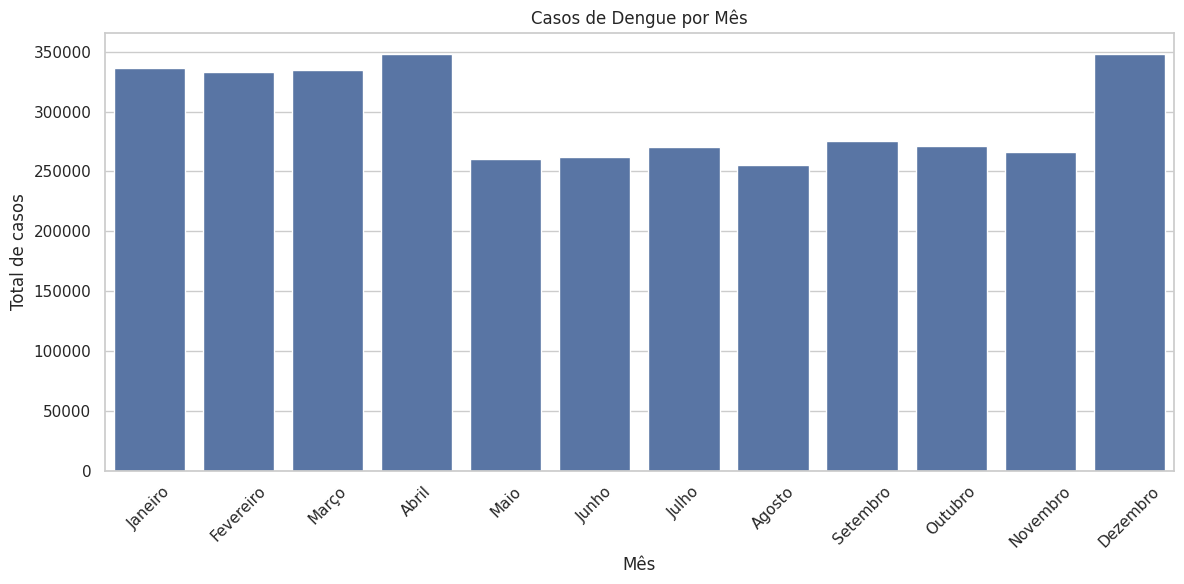

In [14]:
# Análise da sazonalidade dos casos de dengue

casos_por_mes = (
    df.groupby(["mes", "mes_nome"])["casos_dengue"]
    .sum()
    .reset_index()
    .sort_values("mes")
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=casos_por_mes,
    x="mes_nome",
    y="casos_dengue"
)

plt.title("Casos de Dengue por Mês")
plt.xlabel("Mês")
plt.ylabel("Total de casos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

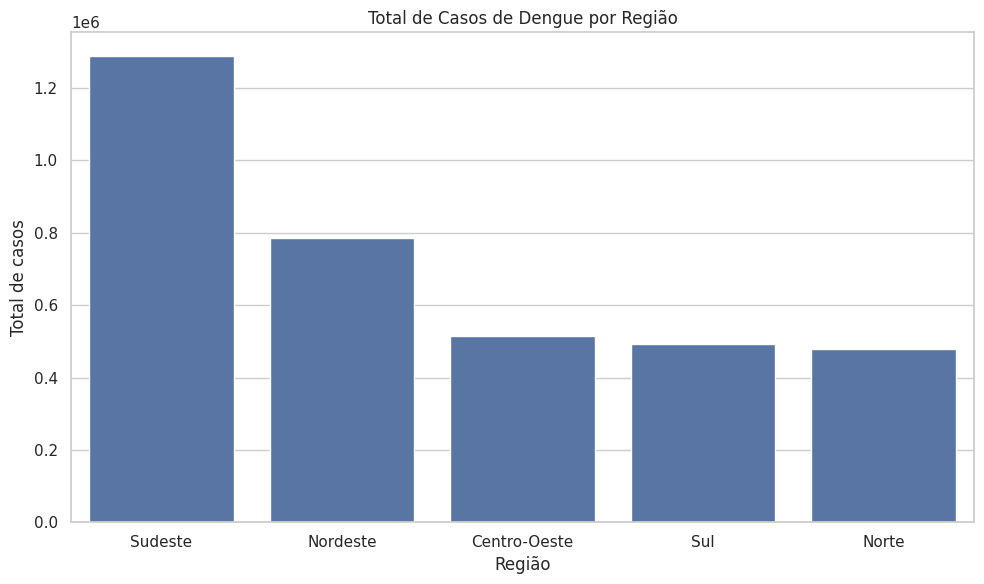

In [15]:
# Comparação dos casos de dengue por região

casos_por_regiao = (
    df.groupby("regiao")["casos_dengue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=casos_por_regiao,
    x="regiao",
    y="casos_dengue"
)

plt.title("Total de Casos de Dengue por Região")
plt.xlabel("Região")
plt.ylabel("Total de casos")
plt.tight_layout()
plt.show()

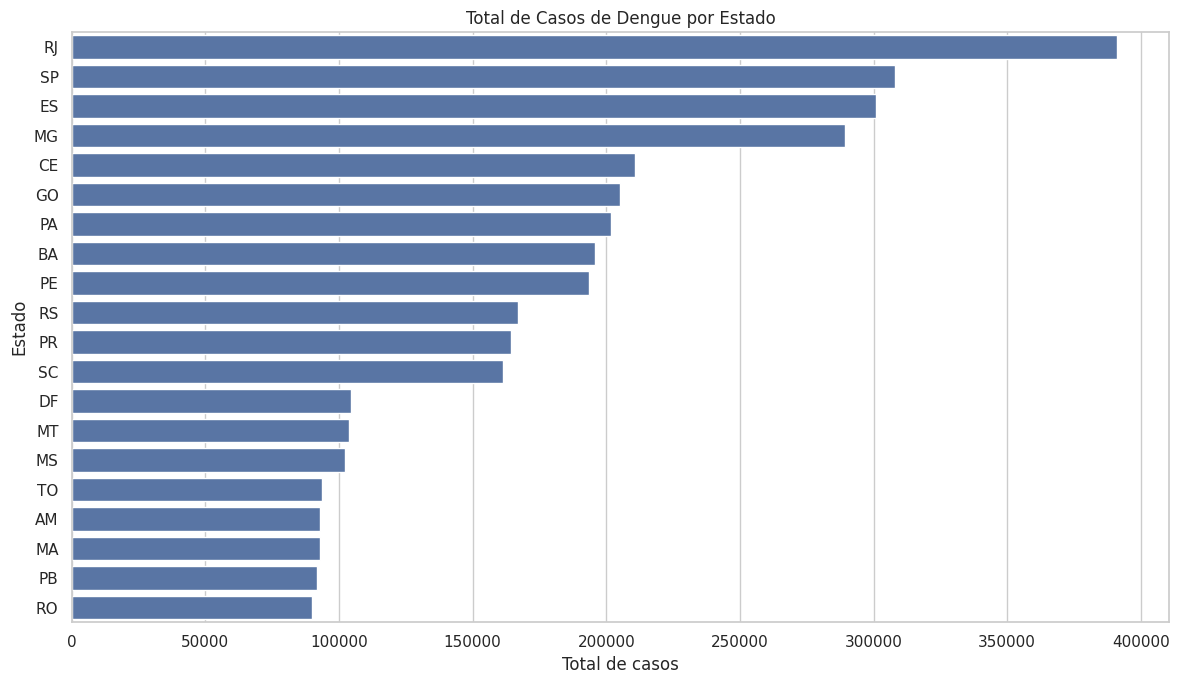

In [16]:
# Comparação dos casos de dengue por estado

casos_por_uf = (
    df.groupby("uf")["casos_dengue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=casos_por_uf,
    x="casos_dengue",
    y="uf"
)

plt.title("Total de Casos de Dengue por Estado")
plt.xlabel("Total de casos")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()

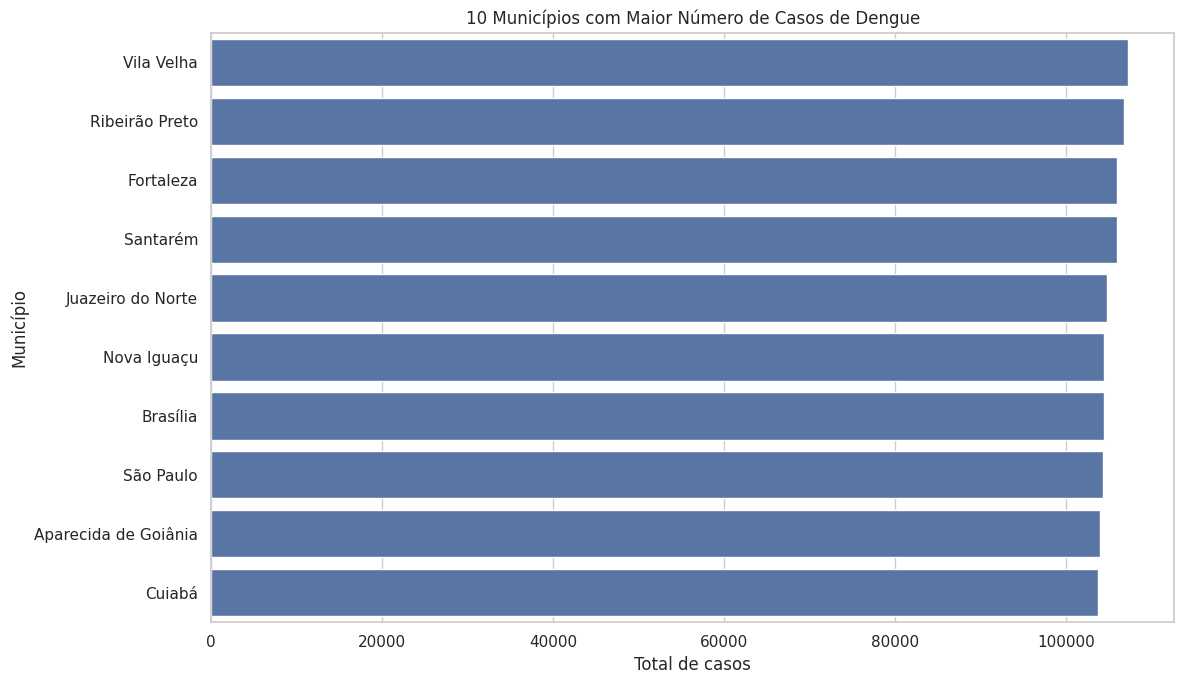

In [17]:
# Ranking dos municípios com mais casos de dengue

casos_por_municipio = (
    df.groupby("municipio")["casos_dengue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=casos_por_municipio,
    x="casos_dengue",
    y="municipio"
)

plt.title("10 Municípios com Maior Número de Casos de Dengue")
plt.xlabel("Total de casos")
plt.ylabel("Município")
plt.tight_layout()
plt.show()

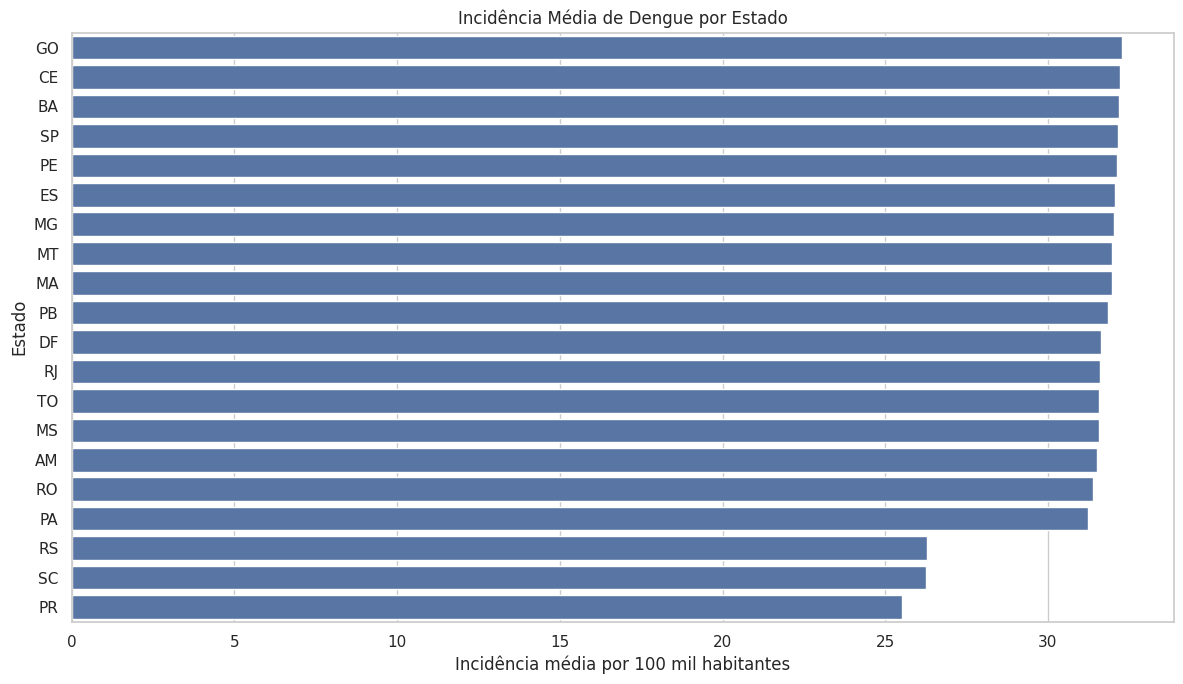

In [18]:
# Incidência média de dengue por estado

incidencia_por_uf = (
    df.groupby("uf")["incidencia_100k"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=incidencia_por_uf,
    x="incidencia_100k",
    y="uf"
)

plt.title("Incidência Média de Dengue por Estado")
plt.xlabel("Incidência média por 100 mil habitantes")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()

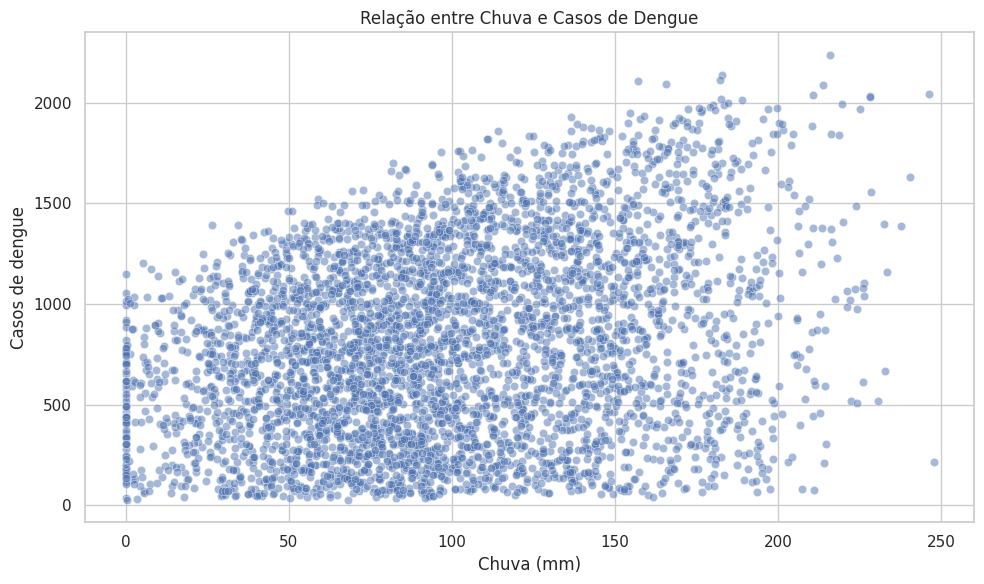

In [19]:
# Relação entre chuva e casos de dengue

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="chuva_mm",
    y="casos_dengue",
    alpha=0.5
)

plt.title("Relação entre Chuva e Casos de Dengue")
plt.xlabel("Chuva (mm)")
plt.ylabel("Casos de dengue")
plt.tight_layout()
plt.show()

In [20]:
# Correlação entre chuva e casos de dengue

correlacao_chuva_dengue = df["chuva_mm"].corr(df["casos_dengue"])

print(f"Correlação entre chuva e casos de dengue: {correlacao_chuva_dengue:.2f}")

Correlação entre chuva e casos de dengue: 0.29


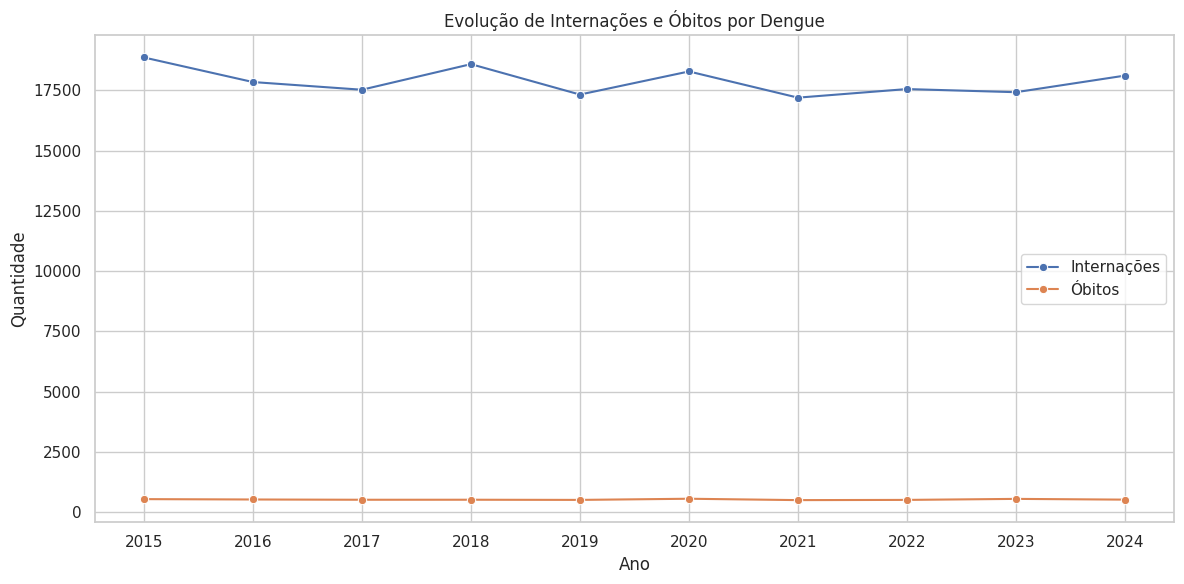

In [21]:
# Evolução das internações e óbitos por ano

saude_por_ano = (
    df.groupby("ano")[["internacoes", "obitos"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=saude_por_ano,
    x="ano",
    y="internacoes",
    marker="o",
    label="Internações"
)

sns.lineplot(
    data=saude_por_ano,
    x="ano",
    y="obitos",
    marker="o",
    label="Óbitos"
)

plt.title("Evolução de Internações e Óbitos por Dengue")
plt.xlabel("Ano")
plt.ylabel("Quantidade")
plt.xticks(saude_por_ano["ano"])
plt.legend()
plt.tight_layout()
plt.show()

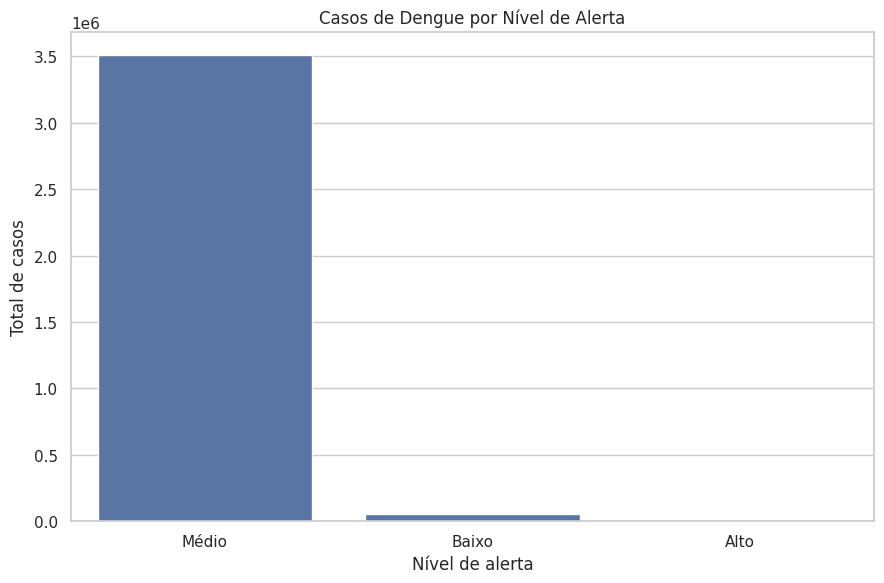

In [22]:
# Análise dos níveis de alerta

casos_por_alerta = (
    df.groupby("nivel_alerta")["casos_dengue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=casos_por_alerta,
    x="nivel_alerta",
    y="casos_dengue"
)

plt.title("Casos de Dengue por Nível de Alerta")
plt.xlabel("Nível de alerta")
plt.ylabel("Total de casos")
plt.tight_layout()
plt.show()

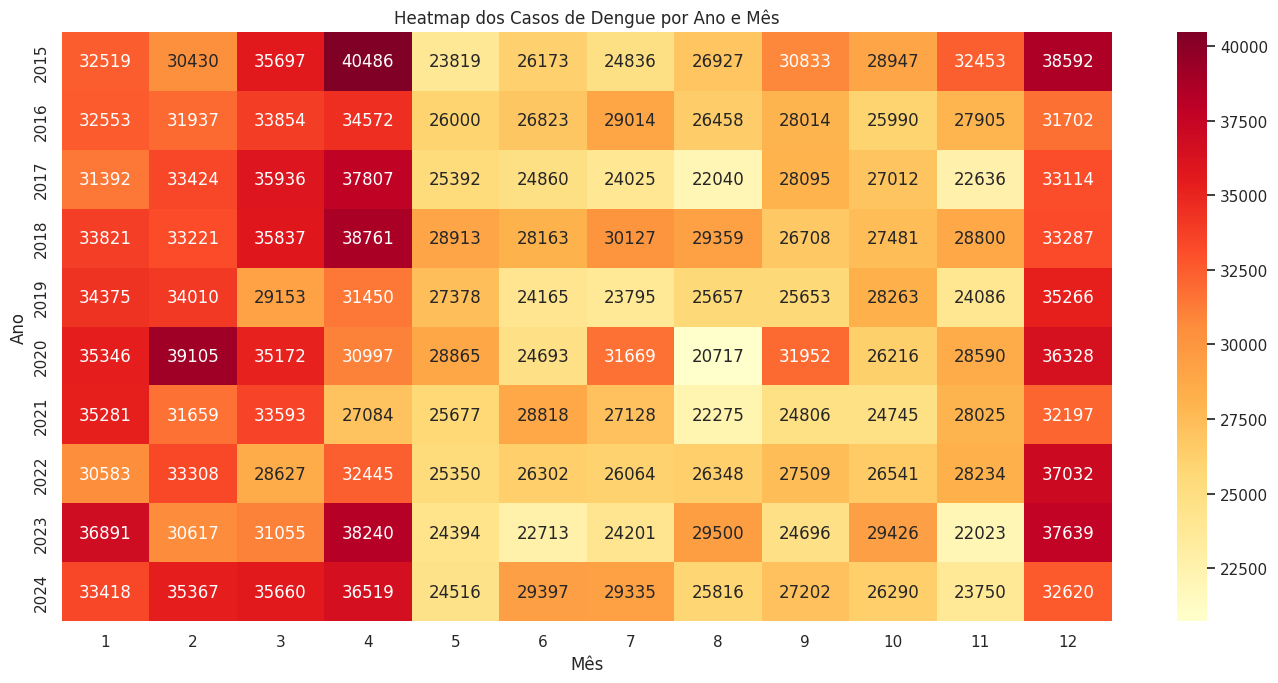

In [23]:
# Heatmap dos casos de dengue por ano e mês

casos_ano_mes = (
    df.groupby(["ano", "mes"])["casos_dengue"]
    .sum()
    .reset_index()
)

tabela_heatmap = casos_ano_mes.pivot(
    index="ano",
    columns="mes",
    values="casos_dengue"
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    tabela_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Heatmap dos Casos de Dengue por Ano e Mês")
plt.xlabel("Mês")
plt.ylabel("Ano")
plt.tight_layout()
plt.show()

Matriz de correlação:


,chuva_mm,temperatura_media,casos_dengue,internacoes,obitos,incidencia_100k
chuva_mm,1.000000,-0.002282,0.292390,0.278664,0.160796,0.829111
temperatura_media,-0.002282,1.000000,0.168767,0.155723,0.093670,0.498920
casos_dengue,0.292390,0.168767,1.000000,0.965648,0.527332,0.331593
internacoes,0.278664,0.155723,0.965648,1.000000,0.511280,0.313150
obitos,0.160796,0.093670,0.527332,0.511280,1.000000,0.181482
incidencia_100k,0.829111,0.498920,0.331593,0.313150,0.181482,1.000000


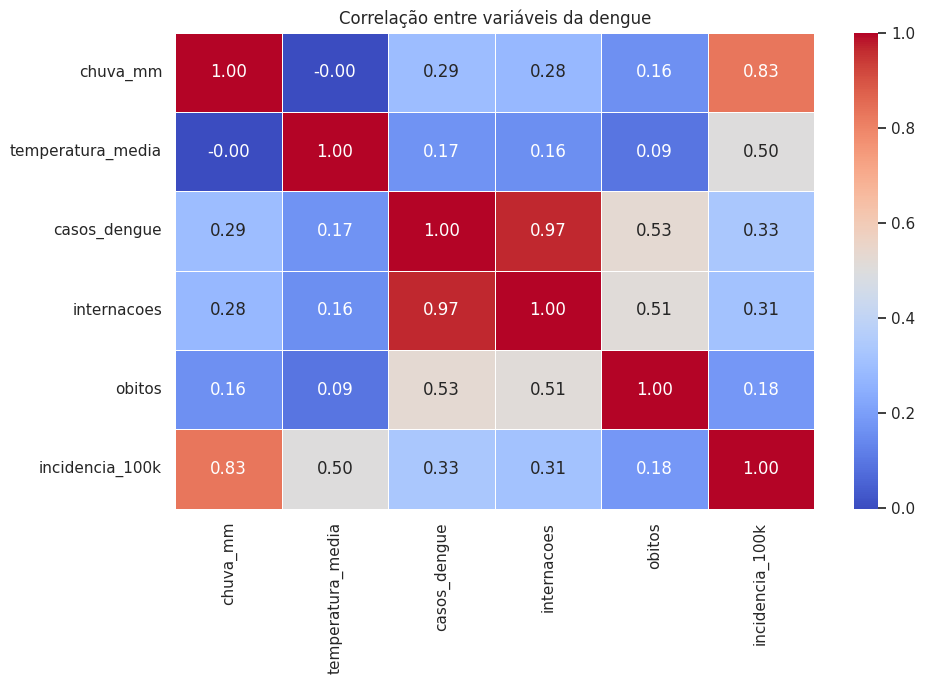

Correlação entre volume de chuva e casos de dengue: 0.29
Correlação entre temperatura e casos de dengue: 0.17


In [27]:
# ============================================================
# RECURSO AVANÇADO 2 — ANÁLISE DE CORRELAÇÃO
# ============================================================

variaveis_correlacao = [
    "chuva_mm",
    "temperatura_media",
    "casos_dengue",
    "internacoes",
    "obitos",
    "incidencia_100k"
]

# Criação da matriz de correlação
matriz_correlacao = df[variaveis_correlacao].corr()

print("Matriz de correlação:")
display(matriz_correlacao)

# Mapa de calor
plt.figure(figsize=(10, 7))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlação entre variáveis da dengue")
plt.tight_layout()
plt.show()

# Correlação entre chuva e casos
correlacao_chuva_casos = df["chuva_mm"].corr(
    df["casos_dengue"]
)

print(
    f"Correlação entre volume de chuva e casos de dengue: "
    f"{correlacao_chuva_casos:.2f}"
)

# Correlação entre temperatura e casos
correlacao_temperatura_casos = df["temperatura_media"].corr(
    df["casos_dengue"]
)

print(
    f"Correlação entre temperatura e casos de dengue: "
    f"{correlacao_temperatura_casos:.2f}"
)

## Interpretação dos resultados

A análise dos dados de dengue no Brasil entre 2015 e 2024 permitiu identificar diferentes padrões relacionados à distribuição dos casos, sazonalidade e fatores ambientais.

Ao longo do período analisado, foram registrados **3.560.562 casos de dengue** e **5.314 óbitos**. A média mensal foi de aproximadamente **29.671 casos**.

Na comparação entre as regiões brasileiras, a **Região Sudeste** apresentou a maior quantidade de casos no período analisado. Entre os estados, o **Rio de Janeiro (RJ)** apresentou o maior número total de casos.

Na análise dos municípios, **Vila Velha** apresentou o maior número acumulado de casos entre os municípios presentes na base de dados.

A análise mensal permitiu observar a existência de períodos de maior concentração dos casos, indicando um comportamento sazonal da dengue. O heatmap também possibilitou identificar visualmente os anos e meses com maior intensidade de casos.

Em relação às condições climáticas, a correlação entre chuva e casos de dengue foi de **0,29**, indicando uma relação positiva, porém fraca. Isso significa que períodos com maior volume de chuva apresentam certa associação com o aumento dos casos, mas a chuva isoladamente não é suficiente para explicar a ocorrência da doença.

A correlação entre a temperatura média e os casos de dengue foi de **0,17**, também indicando uma relação positiva, porém fraca. Esse resultado sugere que a temperatura, isoladamente, apresenta pouca relação linear com a quantidade de casos observada na base analisada.

Entre os resultados encontrados, destaca-se a correlação de **0,97 entre casos de dengue e internações**, indicando uma relação positiva muito forte entre essas variáveis. Dessa forma, os períodos com maior quantidade de casos também tendem a apresentar maior quantidade de internações.

A análise de internações e óbitos permitiu observar a evolução dos impactos mais graves associados à dengue ao longo dos anos. Já a distribuição por nível de alerta ajudou a identificar os períodos classificados como de maior atenção na base analisada.

De maneira geral, os resultados mostram que a dengue apresenta uma distribuição desigual no território brasileiro e possui comportamento temporal e sazonal. As análises também indicam que fatores climáticos, como chuva e temperatura, apresentam correlações positivas, porém fracas, com os casos de dengue. Essas informações podem auxiliar no planejamento de ações de prevenção, monitoramento epidemiológico e direcionamento de recursos para regiões e períodos de maior risco.

É importante destacar que **correlação não significa causalidade**. Os resultados apresentados representam associações estatísticas encontradas na base de dados analisada e não permitem afirmar que uma variável seja diretamente responsável pelo comportamento de outra.

## Conclusão

A análise dos dados de dengue no Brasil entre 2015 e 2024 permitiu identificar padrões importantes relacionados à evolução temporal, distribuição regional e ocorrência dos casos.

Os resultados mostraram que a dengue apresenta períodos de maior concentração de casos e uma distribuição desigual entre regiões, estados e municípios. A análise também permitiu identificar relações entre os casos e variáveis como chuva, temperatura, internações e óbitos.

A análise de correlação mostrou uma relação positiva, porém fraca, entre chuva e casos de dengue, com coeficiente de 0,29, e entre temperatura e casos, com coeficiente de 0,17. Por outro lado, foi identificada uma forte correlação entre casos de dengue e internações, com coeficiente de 0,97.

A utilização de técnicas de análise exploratória, visualização de dados, séries temporais e correlação possibilitou transformar os dados em informações mais claras para a interpretação do problema.

Por fim, os resultados obtidos serviram como base para o desenvolvimento de um dashboard interativo utilizando Streamlit, permitindo que os dados sejam explorados por meio de filtros, indicadores e gráficos.

Dessa forma, o projeto demonstra como a análise e visualização de dados podem contribuir para uma compreensão mais clara do comportamento da dengue e auxiliar na identificação de períodos e regiões que merecem maior atenção.